**Time Allowed -- 45 mins and 5 mins for submission of .ipynb file**

---


No Internet Browser is alloed except Gogle Collab.

---


You can use Google Collab / Jupyter notenook to solve Qiz.

---


Any plagiarism will result in ZERO marks in Quiz

---


**Total Marks -- 25**

---


**Weightage -- 4-5 absolutes**

---


You only have to submit .ipynb file with your roll num **21L-XXXX**  as file name.

In [1]:
import pandas as pd
import numpy as np
import random

# Create a DataFrame with 500 rows and realistic column names
num_rows = 500  # Number of rows in the dataset

# Generate random data for columns with realistic names
data = {
    "Age": [random.randint(18, 65) for _ in range(num_rows)],
    "Weight (kg)": [random.uniform(45, 100) for _ in range(num_rows)],
    "Salary ($)": [random.randint(30000, 120000) for _ in range(num_rows)],
    "Height (cm)": [random.uniform(150, 200) for _ in range(num_rows)],
    "Experience (years)": [random.uniform(0, 20) for _ in range(num_rows)]
}

# Introduce outliers in some columns
outliers_count = 10  # Number of outliers to add to each column

for col_name in ["Age", "Weight (kg)", "Salary ($)", "Height (cm)", "Experience (years)"]:
    outliers_indices = random.sample(range(num_rows), min(outliers_count, num_rows))
    for _ in range(min(outliers_count, num_rows)):
        data[col_name][outliers_indices.pop()] = random.randint(200, 1000)

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Display the first few rows of the dataset
print(df.head())
# saving the dataframe
df.to_csv('data.csv', index=False)

   Age  Weight (kg)  Salary ($)  Height (cm)  Experience (years)
0   30    92.388879       86455   172.173687          448.000000
1   51    78.188772      118988   194.525990            1.004674
2   30    62.682849      102980   172.602686            7.821855
3   39    60.396662       71933   186.487890           13.479906
4   44    53.545501       77671   152.959301            8.581866


You are given a dataset of 500 numerical values. Among these values, there are outliers in some columns. Your task is to identify and report the outliers. Write a Python function named 'find_outliers' that takes the dataset as input and returns count of the outliers from each column.

## Using IQR Question

In [2]:
import pandas as pd
import numpy as np

# Load the dataset from a CSV file
df = pd.read_csv("data.csv")

# Function to count outliers using IQR method for a specific column
def find_outliers(column):
    # TODO: Implement the IQR method to count outliers for the column
    Q1 = np.percentile(column, 25)
    Q3 = np.percentile(column, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (column < lower_bound) | (column > upper_bound)

# Dictionary to store outlier counts for each column
outlier_counts = {}

# Iterate through columns and count outliers
for col_name in df.columns:
    column = df[col_name]
    # TODO: Call the find_outliers function for the column
    outlier_counts[col_name] = find_outliers(df[col_name]).sum()
    # and store the count in the outlier_counts dictionary

# Display the count of outliers for each column
for col_name, count in outlier_counts.items():
    print(f"Number of outliers in '{col_name}': {count}")

Number of outliers in 'Age': 10
Number of outliers in 'Weight (kg)': 10
Number of outliers in 'Salary ($)': 0
Number of outliers in 'Height (cm)': 9
Number of outliers in 'Experience (years)': 10


**QUESTION-2**
Your are provided with a image. Resize it to suitable size according to binary bit planes. Convert this image to grayscale image. Replicate the row 1 before first row, column 1 before first column, last column after last column and last row after last row ---- padding of one row and one column.

 Then, write a program to smoothen a greyscale image by a **3X3** smoothing filter, which *emphasizes* on the current pixel value, gives more weightage to its **4-neighbors** and much less weightage to the **8-neighbor** pixels. Compare the result with filter2D built-in function. Use Kernel/filter [1 0 1 , 0 5 0 , 2 0 2]

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

In [4]:
image = cv2.imread('testimage.png')
cv2.imshow('Image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
gray_image = (0.3 * image[:, :, 2] + 0.59 * image[:, :, 1] + 0.11 * image[:, :, 0]).astype('uint8')
cv2.imshow('Grayscale Image', gray_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

# TODO: Implement the above requirements
# Aply filter2D function

In [9]:
gray_image = cv2.imread('testimage.png', cv2.IMREAD_GRAYSCALE)
equalized_image = cv2.equalizeHist(gray_image)

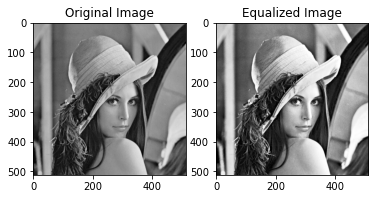

In [11]:
plt.subplot(121), plt.imshow(gray_image, cmap='gray')
plt.title('Original Image')
plt.subplot(122), plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image')
plt.show()


In [10]:
resized_image = cv2.resize(image, (16, 16))
import numpy as np
kernel = np.array([[1, 0, 1],
                   [0, 5, 0],
                   [2, 0, 2]], dtype=np.float32)
filtered_image = cv2.filter2D(resized_image, -1, kernel)
cv2.imshow('Resized Image', resized_image)
cv2.imshow('Filtered Image', filtered_image)
cv2.waitKey(0)
cv2.destroyAllWindows()